# Linear Regression:

Y = wX + b

Y --> Dependent Variable

X --> Independent Variable

w --> weight ( SLOPE )

b --> bias ( INTERCEPT )

## Gradient Descent:

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w = w - α*dw

b = b - α*db

## Learning Rate ( α ):

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

DW = 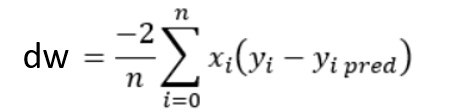

Db = 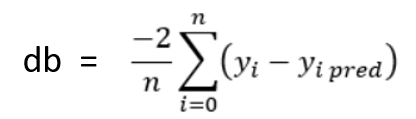

## Workflow

1. Create a Linear Regression class with the following objects <br>
    a. __init__(self,hyperparameters) <br>
    b. fit(X,y) <br>
    c. update_weights() <br>
    d. predict() <br>
2. Define working parameters ( hyper-parameters ) -> learning rate and Number of Iterations
3. I have choosen R2 Score for interpreting the performance of the model.

Formula for R2 Score


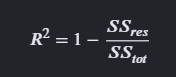


Where 
1. SS(res) -> SUM of Squared Residuals
2. SS(tot) -> Total Sum of Squares


In [1]:
# importing the required Libraries 

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class linear_regression_from_scratch():
    '''CAN BE USED FOR MULTIPLE LINEAR REGRESSION AS WELL '''
    def __init__(self , learning_rate = 0.0001 , no_of_iteration=1000):
        self.learning_rate = learning_rate  # Default learning rate -> 0.01 
        self.no_of_iteration = no_of_iteration # Default Leaning rate -> 100
        self.R2score = None    
    
    def fit(self,X,y):
            
        self.m , self.n = X.shape # get the rows and columns
        
        # inititalizing the weight(slope) and bias(intercept)
        
        self.w = np.zeros(self.n)  # initiating the slope as 0 for every point
        self.b = 0                 # since intercept is only one we don't create a nmupy array
        self.X = X
        self.y = y
        
        self.cost = []             # to store the cost function values
        # implementing Gradient Decent
        for i in range(self.no_of_iteration):
            gradient_norm = self.update_weights()
    
            if gradient_norm < 1e-6:   # stop at 10^(-6) value of cost function.
                break
        
        y_predictions = self.predict(self.X)
        
        # Calculating the R2 Score after finding the best fit line parameters
        ss_total = np.sum((self.y - np.mean(self.y)) ** 2)
        ss_residual = np.sum((self.y - y_predictions) ** 2)
        self.R2score = 1 - (ss_residual / ss_total)
    
    def update_weights(self):
        '''
        This Function Calculates the new slope and new intercept, using the above formula
        '''
        y_predictions = self.predict(self.X)
        
        # calculate gradients
        
        dw = -(2* (self.X.T).dot(self.y - y_predictions)) / self.m
        db = - 2 * np.sum(self.y - y_predictions)/self.m
        
        # updating the parameters 
        
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db
        
        cost = np.mean((self.y - y_predictions) ** 2)
        self.cost.append(cost)
        
        return np.linalg.norm(dw)   
    
    def predict(self,X):
        '''This Functions helps in predicting the value for the test dataset '''
        
        return X.dot(self.w) + self.b

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('salary_data.csv')

In [5]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [6]:
X = df[['YearsExperience']]
y = df['Salary']

In [7]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [8]:
model = linear_regression_from_scratch(learning_rate=0.0005 , no_of_iteration= 4000)

model.fit(X_train,y_train)
print("Training R2 Score : ",model.R2score)

Training R2 Score :  0.9136860930123964


In [9]:
print("Slope:", model.w)
print("Intercept:", model.b)

Slope: YearsExperience    10964.921207
dtype: float64
Intercept: 15159.411450873336


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model_lr = LinearRegression()

model_lr.fit(X_train,y_train)

print("Training for Actual Linear Regression : ",model_lr.score(X_train,y_train))
print(model_lr.coef_)
print(model_lr.intercept_)

Training for Actual Linear Regression :  0.9523132980157709
[9277.53004965]
27032.859591365035


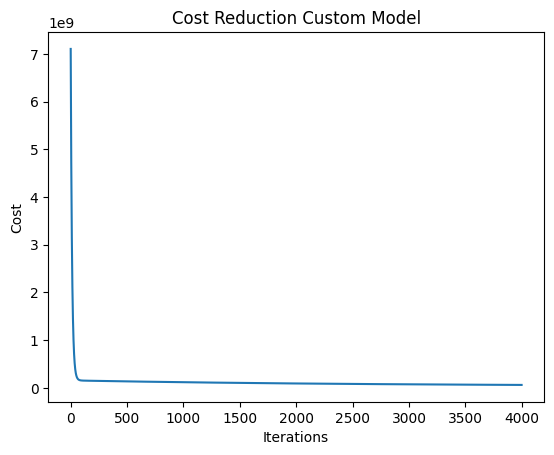

In [11]:
plt.plot(model.cost)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Custom Model")
plt.show()

Observation 

1. Model Converges at around 5000 iterations.

In [12]:
# Comparing Custom Model vs Sklearn Model

y_pred = model.predict(X_test)
y_pred_lr = model_lr.predict(X_test)


print("CUSTOM MODEL : ",r2_score(y_test,y_pred))
print("SKLEARN MODEL : ",r2_score(y_test,y_pred_lr))

CUSTOM MODEL :  0.9264841972831139
SKLEARN MODEL :  0.9517416173163974


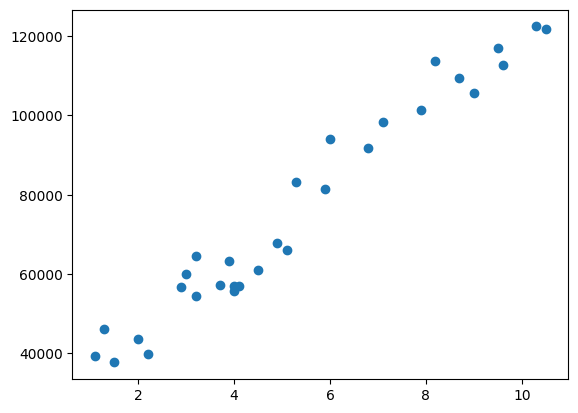

In [13]:
# Visualizing the plots

plt.scatter(X,y)

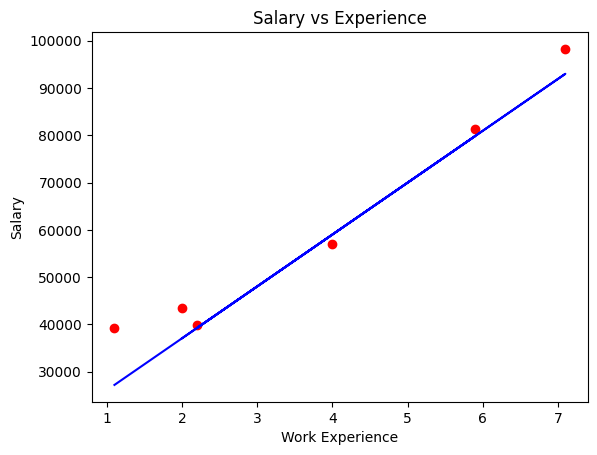

In [35]:
plt.scatter( X_test, y_test, color = 'red' )
plt.plot( X_test, y_pred, color = 'blue' )    
plt.xlabel( 'Work Experience' )
plt.ylabel( 'Salary' )
plt.title( 'Salary vs Experience' )
plt.show()

# Testing Multiple Linear_regression
1. Data set -> Car_dheko

In [15]:
df1 = pd.read_csv('cardekho_imputated.csv')

In [16]:
## Remove Unnecessary Columns
df1.drop('car_name', axis=1, inplace=True)
df1.drop('brand', axis=1, inplace=True)

In [17]:
X1 = df1.drop(['selling_price'], axis=1)
y1 = df1['selling_price']

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X1['model']=le.fit_transform(X1['model'])

In [20]:
# Create Column Transformer with 3 types of transformers
num_features = X1.select_dtypes(exclude="object").columns
onehot_columns = ['seller_type','fuel_type','transmission_type']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, onehot_columns),
        ("StandardScaler", numeric_transformer, num_features)
        
    ],remainder='passthrough'
    
)

In [21]:
X1=preprocessor.fit_transform(X1)

In [22]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1,test_size=0.2,random_state=42)
X1_train.shape, X1_test.shape

((12328, 15), (3083, 15))

## Custom Model Training ( Multiple Linear Regression )

In [25]:
model_mlr = linear_regression_from_scratch(learning_rate=0.005 , no_of_iteration= 10000)

model_mlr.fit(X1_train,y1_train)

In [26]:
print(model_mlr.R2score)

0.6204113185713558


In [ ]:
CM_pred_mlr = model_mlr.predict(X1_test)

In [29]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X1_train,y1_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
sklearn_model_pred = sklearn_model.predict(X1_test)

In [34]:
print("MODEL COMPARISION : ")

print("CUSTOM MODEL ( MULTIPLE LINEAR REGRESSION ) -> ",r2_score(y1_test,CM_pred_mlr))
print("SKLEARN MODEL ( MULTIPLE LINEAR REGRESSION ) -> ",r2_score(y1_test,sklearn_model_pred))

MODEL COMPARISION : 
CUSTOM MODEL ( MULTIPLE LINEAR REGRESSION ) ->  0.6627252882099117
SKLEARN MODEL ( MULTIPLE LINEAR REGRESSION ) ->  0.6644595369594529
